# CRISPR Repair Prediction
***Artificial Intelligence For Science - 4960*** <br>
***Task Two - Traditional AI: Support Vector Regression (SVR), Random Forest Regression, Gradient Boosting Regression*** <br>
***By: Swaroop Sridhar*** <br>


### Overview
This code creates a machine learning pipeline to predict various CRISPR repair outcomes using DNA sequence data. The pipeline processes raw DNA sequences, trains multiple models, and evaluates their performance through comprehensive visualizations.


### Block 1: Initial Setup
**Purpose**: 
- Imports necessary libraries
- Loads CRISPR dataset
- Retrieves list of repair outcome labels to predict
- Sets up foundation for data processing

In [56]:
import numpy as np
import pandas as pd
from tdc.single_pred import CRISPROutcome
from tdc.utils import retrieve_label_name_list

# Get all label names
label_list = retrieve_label_name_list('Leenay')
print("Available repair outcome labels:", label_list)

Available repair outcome labels: ['Fraction_Insertions', 'Avg_Insertion_Length', 'Avg_Deletion_Length', 'Indel_Diversity', 'Fraction_Frameshifts']


### Block 2: DNA Sequence Encoding
**Purpose**:
- Defines function to convert DNA sequences into numerical format
- Implements one-hot encoding for ACGT nucleotides
- Makes DNA sequences readable for machine learning models
- Transforms biological data into computational inputs

In [57]:
def encode_sequence(seq):
    """
    Convert DNA sequence to one-hot encoded matrix
    """
    nucleotides = 'ACGT'
    encoding = np.zeros((len(seq), len(nucleotides)))
    for i, nuc in enumerate(seq):
        if nuc in nucleotides:
            encoding[i, nucleotides.index(nuc)] = 1
    return encoding.flatten()

### Block 3: Data Preparation
**Purpose**:
- Prepares data for model training
- Splits data into training and testing sets
- Processes DNA sequences into encoded format
- Scales features for standardization
- Creates organized dataset structure for model input

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def prepare_data(label_name):
    """
    Prepare data for a specific repair outcome label
    """
    data = CRISPROutcome(name='Leenay', label_name=label_name)
    split = data.get_split()
    
    # Combine guide and PAM sequences
    X_train = pd.DataFrame({'sequence': split['train']['GuideSeq']})  # Changed from 'X' to 'GuideSeq'
    X_test = pd.DataFrame({'sequence': split['test']['GuideSeq']})    # Changed from 'X' to 'GuideSeq'
    
    # Encode sequences
    X_train_encoded = np.vstack(X_train['sequence'].apply(encode_sequence))
    X_test_encoded = np.vstack(X_test['sequence'].apply(encode_sequence))
    
    y_train = split['train']['Y']
    y_test = split['test']['Y']
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_encoded)
    X_test_scaled = scaler.transform(X_test_encoded)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

### Block 4: Model Definition and Evaluation
**Purpose**:
- Implements three machine learning models:
  1. Support Vector Regression (SVR)
  2. Random Forest Regression
  3. Gradient Boosting Regression
- Defines training and evaluation procedures
- Calculates performance metrics (MSE and R²)
- Enables model comparison

In [59]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """
    Train and evaluate multiple models on the data
    """
    models = {
        'SVR': SVR(kernel='rbf'),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    predictions = {}
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {'MSE': mse, 'R2': r2}
        predictions[name] = y_pred
        
        print(f"{name} Results:")
        print(f"Mean Squared Error: {mse:.4f}")
        print(f"R-squared Score: {r2:.4f}")
    
    return results, predictions

### Block 5: Training Execution
**Purpose**:
- Executes training pipeline for each repair outcome
- Implements error handling for robustness
- Stores results in organized structure
- Manages model training process

In [60]:
from tdc.utils import retrieve_label_name_list
from tdc.single_pred import CRISPROutcome

# Get all label names and print them to verify
label_list = retrieve_label_name_list('Leenay')
print("Available repair outcome labels:", label_list)

# Dictionary to store results for all labels
all_results = {}

# Process each repair outcome
for label_name in label_list:
    print(f"\nProcessing {label_name}")
    try:
        X_train, X_test, y_train, y_test = prepare_data(label_name)
        results, predictions = train_and_evaluate_models(X_train, X_test, y_train, y_test)
        all_results[label_name] = results
    except Exception as e:
        print(f"Error processing {label_name}: {str(e)}")

Found local copy...
Loading...
Done!


Available repair outcome labels: ['Fraction_Insertions', 'Avg_Insertion_Length', 'Avg_Deletion_Length', 'Indel_Diversity', 'Fraction_Frameshifts']

Processing Fraction_Insertions

Training SVR...
SVR Results:
Mean Squared Error: 0.0123
R-squared Score: 0.4797

Training Random Forest...
Random Forest Results:
Mean Squared Error: 0.0110
R-squared Score: 0.5363

Training Gradient Boosting...


Found local copy...
Loading...
Done!


Gradient Boosting Results:
Mean Squared Error: 0.0101
R-squared Score: 0.5729

Processing Avg_Insertion_Length

Training SVR...
SVR Results:
Mean Squared Error: 1.2450
R-squared Score: 0.0355

Training Random Forest...
Random Forest Results:
Mean Squared Error: 1.3235
R-squared Score: -0.0253

Training Gradient Boosting...


Found local copy...
Loading...
Done!


Gradient Boosting Results:
Mean Squared Error: 1.3863
R-squared Score: -0.0740

Processing Avg_Deletion_Length

Training SVR...
SVR Results:
Mean Squared Error: 9.4230
R-squared Score: 0.0344

Training Random Forest...
Random Forest Results:
Mean Squared Error: 9.0988
R-squared Score: 0.0677

Training Gradient Boosting...


Found local copy...
Loading...
Done!


Gradient Boosting Results:
Mean Squared Error: 9.1190
R-squared Score: 0.0656

Processing Indel_Diversity

Training SVR...
SVR Results:
Mean Squared Error: 0.3855
R-squared Score: 0.2559

Training Random Forest...
Random Forest Results:
Mean Squared Error: 0.3899
R-squared Score: 0.2474

Training Gradient Boosting...


Found local copy...
Loading...
Done!


Gradient Boosting Results:
Mean Squared Error: 0.3739
R-squared Score: 0.2783

Processing Fraction_Frameshifts

Training SVR...
SVR Results:
Mean Squared Error: 0.0186
R-squared Score: -0.0308

Training Random Forest...
Random Forest Results:
Mean Squared Error: 0.0162
R-squared Score: 0.1059

Training Gradient Boosting...
Gradient Boosting Results:
Mean Squared Error: 0.0169
R-squared Score: 0.0651


### Block 6: Individual Performance Visualization
**Purpose**:
- Creates visualizations for each repair outcome
- Displays performance metrics through bar plots
- Compares model effectiveness
- Provides detailed view of model performance

Labels with results: dict_keys(['Fraction_Insertions', 'Avg_Insertion_Length', 'Avg_Deletion_Length', 'Indel_Diversity', 'Fraction_Frameshifts'])
Expected labels: ['Fraction_Insertions', 'Avg_Insertion_Length', 'Avg_Deletion_Length', 'Indel_Diversity', 'Fraction_Frameshifts']


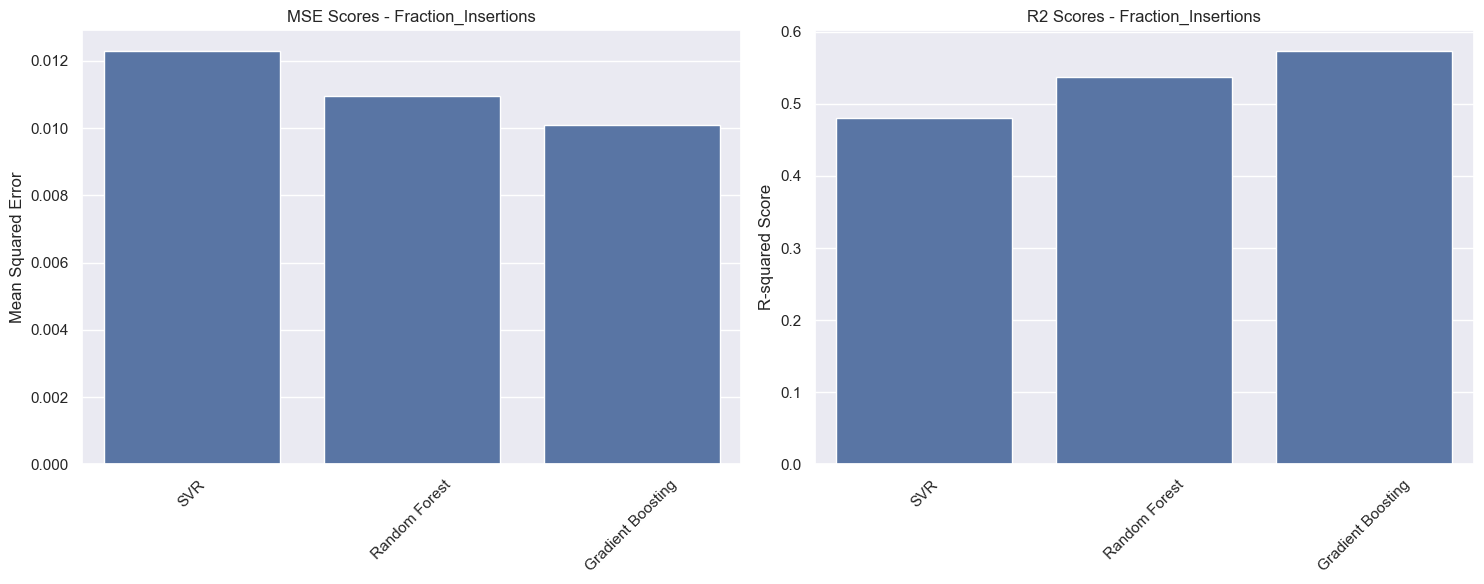

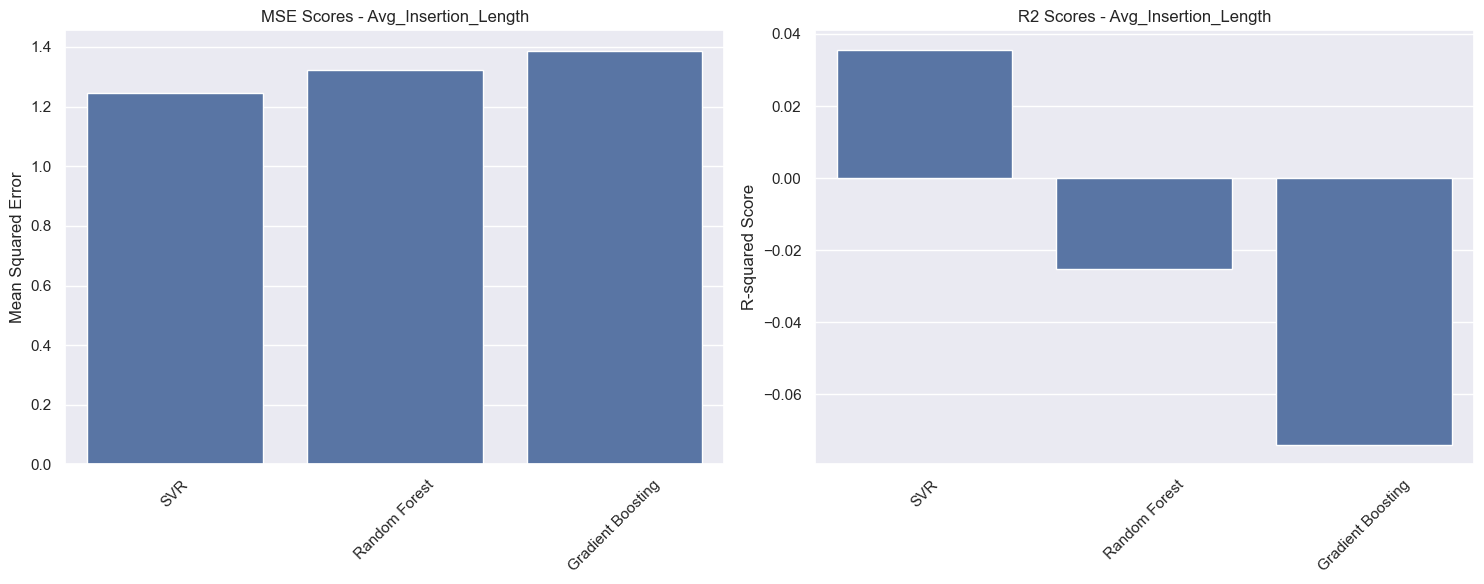

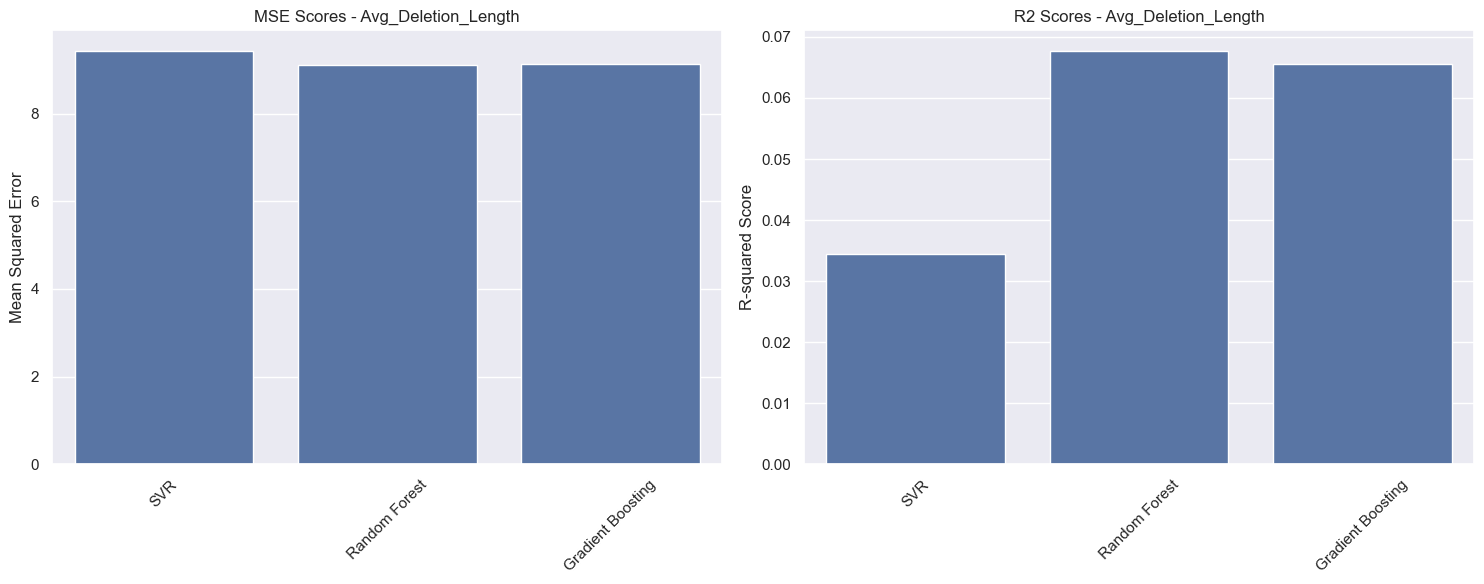

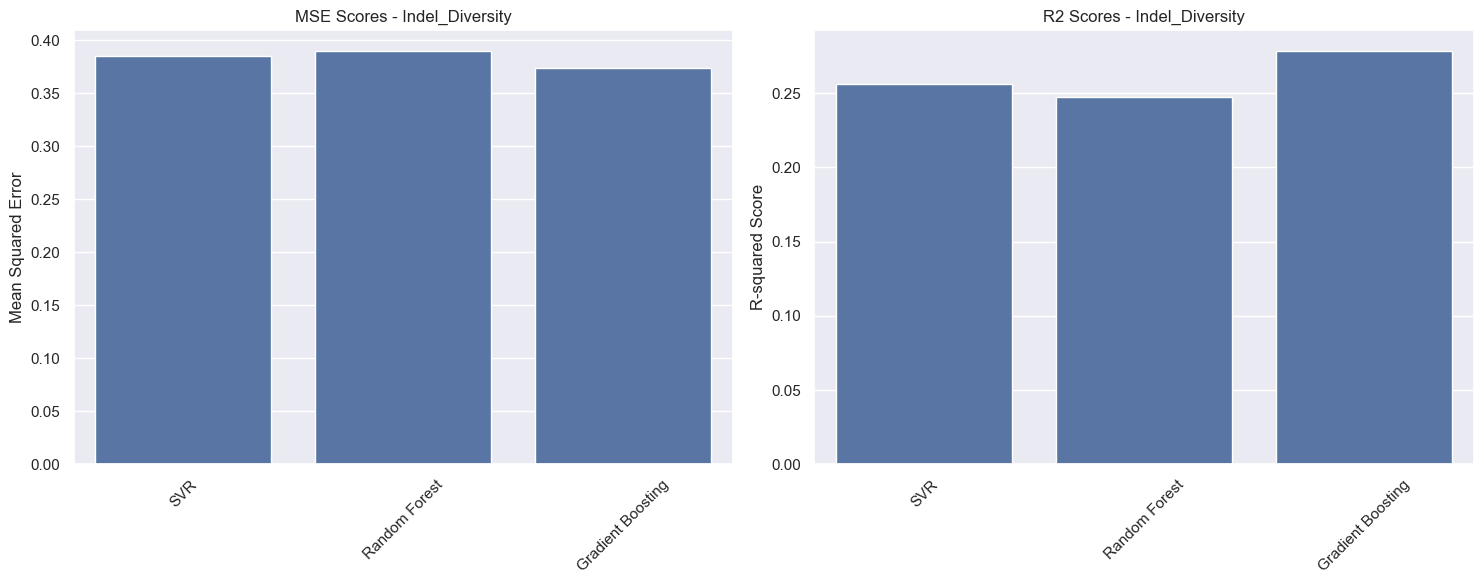

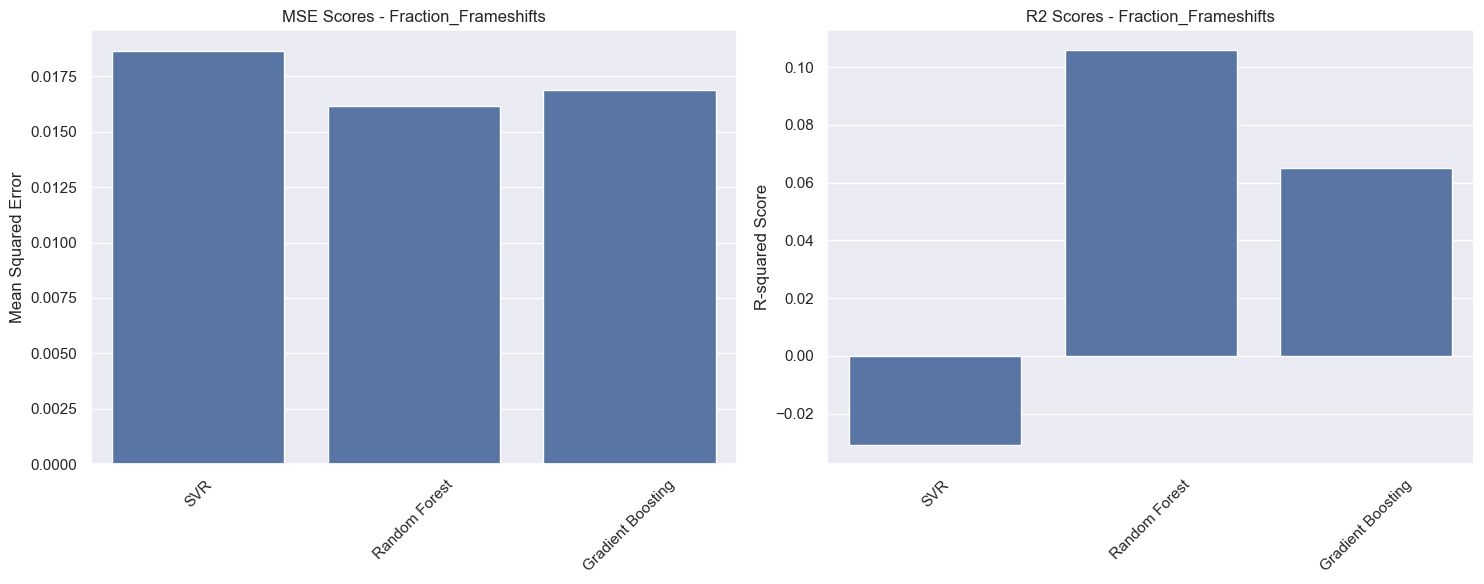

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# First, let's verify what we have
print("Labels with results:", all_results.keys())
print("Expected labels:", label_list)

# Set basic seaborn style properties
sns.set_theme()

# Create subplots for each repair outcome that has results
for label_name in all_results.keys():  # Changed from label_list to all_results.keys()
    results = all_results[label_name]
    
    # Create figure with larger size for better readability
    plt.figure(figsize=(15, 6))
    
    # Plot MSE and R2 scores
    model_names = list(results.keys())
    mse_scores = [results[model]['MSE'] for model in model_names]
    r2_scores = [results[model]['R2'] for model in model_names]
    
    # MSE subplot
    plt.subplot(1, 2, 1)
    sns.barplot(x=model_names, y=mse_scores)
    plt.title(f'MSE Scores - {label_name}')
    plt.xticks(rotation=45)
    plt.ylabel('Mean Squared Error')
    
    # R2 subplot
    plt.subplot(1, 2, 2)
    sns.barplot(x=model_names, y=r2_scores)
    plt.title(f'R2 Scores - {label_name}')
    plt.xticks(rotation=45)
    plt.ylabel('R-squared Score')
    
    plt.tight_layout()
    plt.show()

### Block 7: Comprehensive Performance Analysis
**Purpose**:
- Generates comprehensive performance comparisons
- Visualizes results across all repair outcomes
- Enables model comparison across different metrics
- Provides high-level analysis of model effectiveness

Contents of all_results: {'Fraction_Insertions': {'SVR': {'MSE': np.float64(0.012294524989584776), 'R2': 0.4797461544987618}, 'Random Forest': {'MSE': np.float64(0.01095775344222305), 'R2': 0.5363128407807234}, 'Gradient Boosting': {'MSE': np.float64(0.0100925926986124), 'R2': 0.572922893159441}}, 'Avg_Insertion_Length': {'SVR': {'MSE': np.float64(1.2449891454586357), 'R2': 0.03551167418429313}, 'Random Forest': {'MSE': np.float64(1.32353040181075), 'R2': -0.025333936496599208}, 'Gradient Boosting': {'MSE': np.float64(1.3862917387739682), 'R2': -0.07395490402423999}}, 'Avg_Deletion_Length': {'SVR': {'MSE': np.float64(9.423036165182896), 'R2': 0.03444802628861521}, 'Random Forest': {'MSE': np.float64(9.098787500628275), 'R2': 0.06767287362505958}, 'Gradient Boosting': {'MSE': np.float64(9.119041495335185), 'R2': 0.06559750383744745}}, 'Indel_Diversity': {'SVR': {'MSE': np.float64(0.38549764828969196), 'R2': 0.2558639677740757}, 'Random Forest': {'MSE': np.float64(0.389885839418656), 'R2

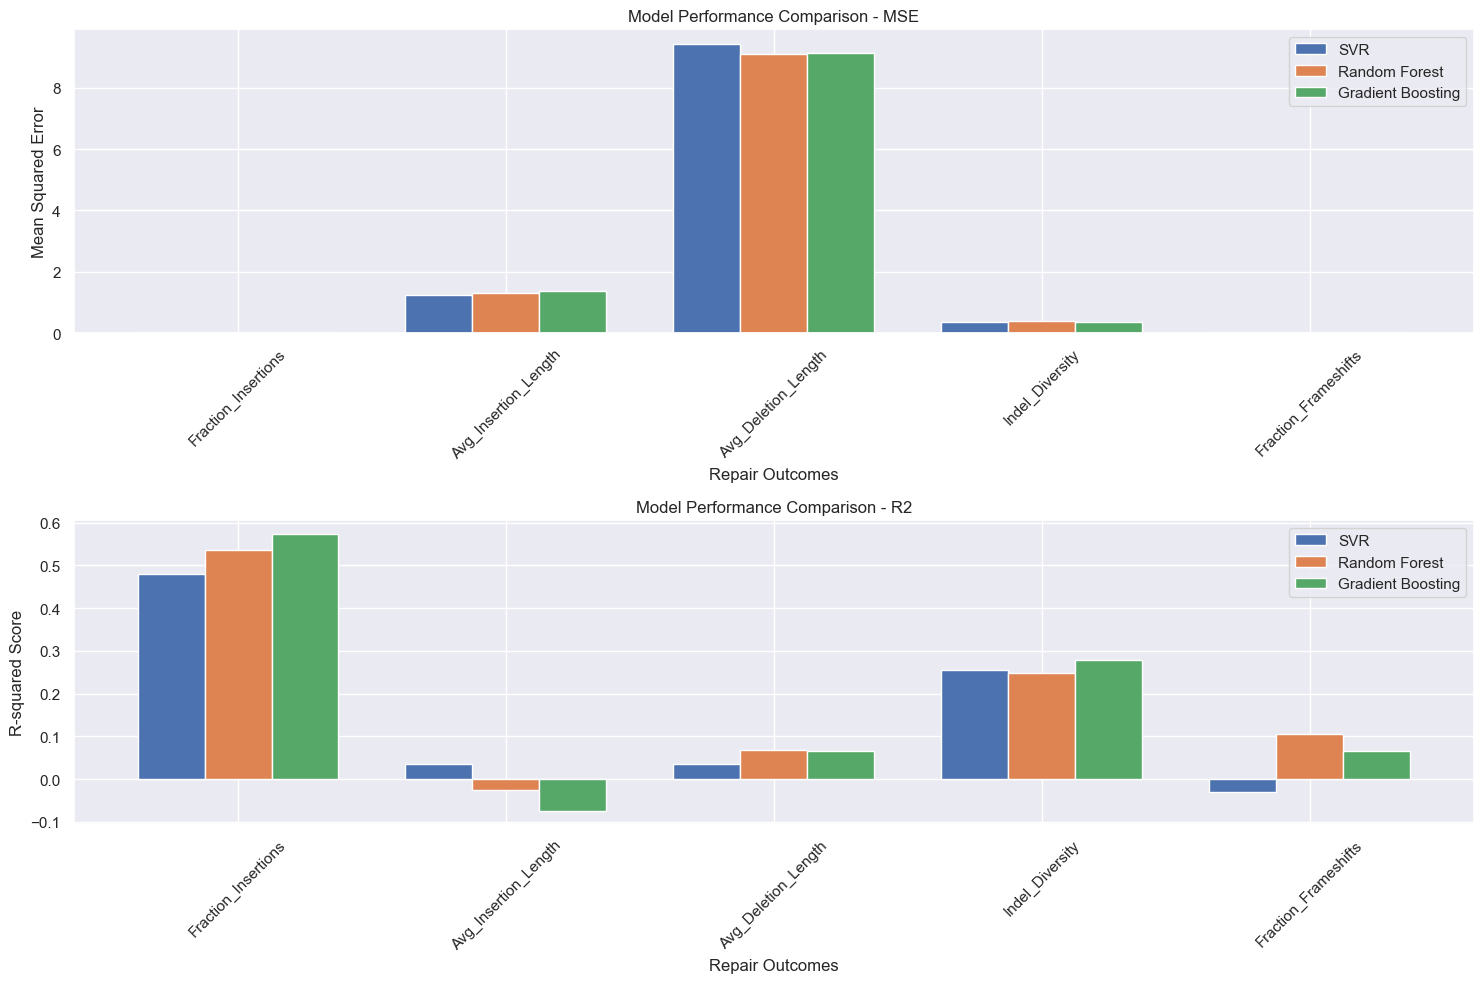

In [62]:
# First, let's debug what we have
print("Contents of all_results:", all_results)
print("Number of results:", len(all_results))

# Only proceed with plotting if we have results
if len(all_results) > 0:
    # Create overall performance comparison plot
    plt.figure(figsize=(15, 10))
    labels = list(all_results.keys())
    model_names = list(all_results[labels[0]].keys())

    # Plot MSE
    plt.subplot(2, 1, 1)
    x = np.arange(len(labels))
    width = 0.25

    for i, model in enumerate(model_names):
        mse_values = [all_results[label][model]['MSE'] for label in labels]
        plt.bar(x + i*width, mse_values, width, label=model)

    plt.xlabel('Repair Outcomes')
    plt.ylabel('Mean Squared Error')
    plt.title('Model Performance Comparison - MSE')
    plt.xticks(x + width, labels, rotation=45)
    plt.legend()

    # Plot R2
    plt.subplot(2, 1, 2)
    for i, model in enumerate(model_names):
        r2_values = [all_results[label][model]['R2'] for label in labels]
        plt.bar(x + i*width, r2_values, width, label=model)

    plt.xlabel('Repair Outcomes')
    plt.ylabel('R-squared Score')
    plt.title('Model Performance Comparison - R2')
    plt.xticks(x + width, labels, rotation=45)
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No results available to plot. Please check if the models were trained successfully.")

## Application
This pipeline is valuable for:
- Predicting CRISPR gene editing outcomes
- Evaluating different machine learning approaches
- Understanding DNA repair mechanisms
- Improving gene editing accuracy